In [36]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

RANDOM_STATE = 42

PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures" / "pca"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [37]:
def safe_filename(text):
    text = str(text)
    text = re.sub(r"[^A-Za-z0-9_\-]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text[:80] if text else "unknown"

def find_file(candidates, search_dirs):
    for directory in search_dirs:
        for name in candidates:
            path = directory / name
            if path.exists():
                return path
    raise FileNotFoundError(f"Could not find any of: {candidates} in {search_dirs}")

SEARCH_DIRS = [DATA_RAW]

FILES = {
    "descriptor": find_file(["Molecular_Descriptor.xlsx"], SEARCH_DIRS),
    "activity": find_file(["ERα_activity.xlsx", "ERa_activity.xlsx"], SEARCH_DIRS),
    "admet": find_file(["ADMET.xlsx"], SEARCH_DIRS)
}

# 1. Load Raw Data

In [38]:
desc_train = pd.read_excel(FILES["descriptor"], sheet_name="training")
desc_test = pd.read_excel(FILES["descriptor"], sheet_name="test")
activity_train = pd.read_excel(FILES["activity"], sheet_name="training")
admet_train = pd.read_excel(FILES["admet"], sheet_name="training")

smiles_col = desc_train.columns[0]
X_train_raw = desc_train.drop(columns=[smiles_col]).copy()
X_test_raw = desc_test.drop(columns=[smiles_col]).copy()

X_train = X_train_raw.apply(pd.to_numeric, errors="coerce")
X_test = X_test_raw.apply(pd.to_numeric, errors="coerce")

print("Descriptor training matrix:", X_train.shape)
print("Descriptor test matrix:", X_test.shape)
print("Activity training table:", activity_train.shape)
print("ADMET training table:", admet_train.shape)

display(desc_train.head(3))

Descriptor training matrix: (1974, 729)
Descriptor test matrix: (50, 729)
Activity training table: (1974, 3)
ADMET training table: (1974, 6)


,SMILES,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,nAromBond,nAtom,nHeavyAtom,nH,nB,nC,nN,nO,nS,nP,nF,nCl,nBr,nI,nX,ATSc1,ATSc2,ATSc3,ATSc4,ATSc5,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,ATSp1,ATSp2,ATSp3,ATSp4,ATSp5,nBase,BCUTw-1l,BCUTw-1h,BCUTc-1l,BCUTc-1h,BCUTp-1l,BCUTp-1h,nBonds,nBonds2,nBondsS,nBondsS2,nBondsS3,nBondsD,nBondsD2,nBondsT,nBondsQ,nBondsM,bpol,C1SP1,C2SP1,C1SP2,C2SP2,C3SP2,...,MDEN-13,MDEN-22,MDEN-23,MDEN-33,MLFER_A,MLFER_BH,MLFER_BO,MLFER_S,MLFER_E,MLFER_L,PetitjeanNumber,nRing,n3Ring,n4Ring,n5Ring,n6Ring,n7Ring,n8Ring,n9Ring,n10Ring,n11Ring,n12Ring,nG12Ring,nFRing,nF4Ring,nF5Ring,nF6Ring,nF7Ring,nF8Ring,nF9Ring,nF10Ring,nF11Ring,nF12Ring,nFG12Ring,nTRing,nT4Ring,nT5Ring,nT6Ring,nT7Ring,nT8Ring,nT9Ring,nT10Ring,nT11Ring,nT12Ring,nTG12Ring,nRotB,LipinskiFailures,TopoPSA,VABC,VAdjMat,MW,WTPT-1,WTPT-2,WTPT-3,WTPT-4,WTPT-5,WPATH,WPOL,XLogP,Zagreb
0,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCC3)c4ccc(OCCN5C...,0,-0.2860,0.081796,126.1188,74.170169,12,12,64,31,33,0,26,1,3,1,0,0,0,0,0,0,0.460175,-0.217040,-0.126453,0.161524,-0.080148,39.811140,40.498576,58.166514,61.613797,58.060335,2469.977567,2930.668527,4109.492845,4128.339568,3792.779760,1,11.85,31.972073,-0.360525,0.185437,5.245435,13.254859,35,68,62,56,23,6,0,0,0,12,44.167831,0,0,0,11,1,...,0.0,0.0,0.0,0.0,0.546,1.801,1.847,2.288,2.529,16.311,0.470588,5,0,0,1,4,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,6,0,1,4,0,0,0,1,0,0,0,6,0,67.23,414.727478,5.954196,439.218115,64.771680,2.089409,15.471445,8.858910,3.406628,3011,47,4.666,166
1,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCCCC3)c4ccc(OCCN...,0,-0.8620,0.743044,131.9420,80.357341,12,12,70,33,37,0,28,1,3,1,0,0,0,0,0,0,0.460175,-0.217040,-0.126453,0.161524,-0.080148,41.811140,42.498576,60.166514,68.613797,60.060335,2679.488262,3157.289284,4379.505354,4811.560374,4154.384741,1,11.85,31.972073,-0.360530,0.185459,5.256770,13.617609,37,74,68,62,25,6,0,0,0,12,48.540659,0,0,0,11,1,...,0.0,0.0,0.0,0.0,0.546,1.801,1.847,2.288,2.529,17.309,0.470588,5,0,0,0,4,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,6,0,0,4,1,0,0,1,0,0,0,6,1,67.23,449.319447,6.044394,467.249415,68.960024,2.089698,15.486947,8.863774,3.406648,3516,54,5.804,174
2,Oc1ccc(cc1)[C@H]2Sc3cc(O)ccc3O[C@H]2c4ccc(OCCN...,0,0.7296,0.532316,139.9304,74.064997,18,18,62,33,29,0,27,1,4,1,0,0,0,0,0,0,0.519350,-0.236031,-0.143126,0.175159,-0.059065,42.585609,42.830668,61.830698,67.277981,60.392427,2576.569862,3054.050592,4285.592752,4479.177597,3993.734054,1,11.85,31.972073,-0.361379,0.116954,4.910140,13.393453,37,66,57,48,19,9,0,0,0,18,39.795003,0,0,0,16,2,...,0.0,0.0,0.0,0.0,1.089,2.141,2.186,2.901,3.133,17.662,0.470588,5,0,0,0,5,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,6,0,0,5,0,0,0,1,0,0,0,6,0,87.46,422.004313,6.044394,463.181729,68.748923,2.083301,18.011114,11.390412,3.406644,3542,52,2.964,176


# 2. Load Data-Audit Outputs

In [39]:
preprocessing_candidates = pd.read_csv(RESULTS_DIR / "descriptor_preprocessing_candidates.csv")
descriptor_category_map = pd.read_csv(RESULTS_DIR / "descriptor_category_map_with_candidate_super_blocks.csv")

print("Loaded preprocessing candidates:", preprocessing_candidates is not None)
print("Loaded descriptor category map:", descriptor_category_map is not None)


Loaded preprocessing candidates: True
Loaded descriptor category map: True


In [40]:
display(preprocessing_candidates.head(10))
print(preprocessing_candidates[["is_constant", "is_near_constant", "is_binary_like", "is_rare_binary_like"]].sum())


,descriptor,variance,std,range,n_unique_values,unique_value_ratio,dominant_value,dominant_value_ratio,is_constant,dominant_value_ge_90pct,dominant_value_ge_95pct,unique_ratio_le_1pct,is_near_constant,descriptor_numeric_type,is_integer_like,is_binary_like,is_low_cardinality,is_continuous_like,is_rare_binary_like,descriptor_category,candidate_super_block,remove_before_pca_pls,review_before_pca_pls,recommended_action
0,nB,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom count,block_Y_topological_connectivity_structure,True,False,remove_constant_descriptor
1,nBondsQ,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Bond count,block_Y_topological_connectivity_structure,True,False,remove_constant_descriptor
2,nHsNH3p,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
3,nHssNH2p,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
4,nHsssNHp,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
5,nHmisc,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
6,nsLi,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
7,nssBe,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
8,nssssBem,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
9,nsBH2,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor


is_constant            225
is_near_constant       184
is_binary_like         241
is_rare_binary_like     15
dtype: int64


### Note on binary near-constant descriptors

A binary descriptor with two unique values and a dominant value above 95% is not mathematically constant. It may represent a rare structural pattern. Such a descriptor is not automatically useless: if the rare state is strongly associated with ERα activity or an ADMET endpoint, it may still be informative in supervised analysis.

However, for unsupervised PCA, rare binary descriptors can have two issues. First, they explain little global variation before scaling. Second, after standardisation, the rare class can create extreme standardised values and affect outlier structure. Therefore, this notebook keeps binary near-constant descriptors in the primary PCA dataset, but removes them in a sensitivity dataset to check whether PCA conclusions are robust.


# 3. Define PCA Input Datasets

The primary PCA dataset removes only constant descriptors. Near-constant variables, including rare binary indicators, are retained initially and examined through sensitivity analysis.


In [41]:
constant_descriptors = preprocessing_candidates.loc[
    preprocessing_candidates["is_constant"].fillna(False).astype(bool), "descriptor"
].tolist()

near_constant_descriptors = preprocessing_candidates.loc[
    preprocessing_candidates["is_near_constant"].fillna(False).astype(bool), "descriptor"
].tolist()

rare_binary_descriptors = preprocessing_candidates.loc[
    preprocessing_candidates["is_rare_binary_like"].fillna(False).astype(bool), "descriptor"
].tolist()

nonbinary_near_constant_descriptors = preprocessing_candidates.loc[
    preprocessing_candidates["is_near_constant"].fillna(False).astype(bool)
    & (~preprocessing_candidates["is_binary_like"].fillna(False).astype(bool)),
    "descriptor"
].tolist()

# Dataset A: primary PCA, remove only constant descriptors
primary_descriptors = [c for c in X_train.columns if c not in constant_descriptors]

# Dataset B: sensitivity, remove constants plus non-binary near-constant descriptors
sensitivity_nonbinary_descriptors = [
    c for c in X_train.columns
    if c not in set(constant_descriptors + nonbinary_near_constant_descriptors)
]

# Dataset C: sensitivity, remove constants plus all near-constant descriptors, including rare binary indicators
sensitivity_all_near_constant_descriptors = [
    c for c in X_train.columns
    if c not in set(constant_descriptors + near_constant_descriptors)
]

dataset_definitions = pd.DataFrame([
    {
        "dataset_name": "primary_remove_constant_only",
        "n_descriptors": len(primary_descriptors),
        "description": "Remove only constant/zero-variance descriptors; keep rare binary and other near-constant descriptors for primary PCA.",
    },
    {
        "dataset_name": "sensitivity_remove_nonbinary_near_constant",
        "n_descriptors": len(sensitivity_nonbinary_descriptors),
        "description": "Remove constant descriptors and non-binary near-constant descriptors; keep rare binary indicators.",
    },
    {
        "dataset_name": "sensitivity_remove_all_near_constant",
        "n_descriptors": len(sensitivity_all_near_constant_descriptors),
        "description": "Remove constant descriptors and all near-constant descriptors, including rare binary indicators.",
    },
])

dataset_definitions.to_csv(RESULTS_DIR / "pca_dataset_definitions.csv", index=False)
display(dataset_definitions)

,dataset_name,n_descriptors,description
0,primary_remove_constant_only,504,Remove only constant/zero-variance descriptors...
1,sensitivity_remove_nonbinary_near_constant,336,Remove constant descriptors and non-binary nea...
2,sensitivity_remove_all_near_constant,320,Remove constant descriptors and all near-const...


# 4. PCA Functions

In [42]:
def fit_standardised_pca(X, descriptors, dataset_name, n_components_max=100):
    X_selected = X[descriptors].copy()
    if X_selected.isna().sum().sum() > 0:
        X_selected = X_selected.fillna(X_selected.median())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_selected)

    n_components = min(n_components_max, X_scaled.shape[0] - 1, X_scaled.shape[1])
    pca = PCA(n_components=n_components, svd_solver="full", random_state=RANDOM_STATE)
    scores = pca.fit_transform(X_scaled)

    explained = pd.DataFrame({
        "dataset_name": dataset_name,
        "component": [f"PC{i+1}" for i in range(n_components)],
        "component_index": np.arange(1, n_components + 1),
        "explained_variance": pca.explained_variance_,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance_ratio": np.cumsum(pca.explained_variance_ratio_),
    })

    score_cols = [f"PC{i+1}" for i in range(min(20, n_components))]
    scores_df = pd.DataFrame(scores[:, :len(score_cols)], columns=score_cols)
    scores_df.insert(0, "SMILES", desc_train[smiles_col].astype(str).values)
    scores_df.insert(0, "dataset_name", dataset_name)

    weights = pd.DataFrame(
        pca.components_[:min(20, n_components), :].T,
        columns=[f"PC{i+1}_weight" for i in range(min(20, n_components))],
    )
    weights.insert(0, "descriptor", descriptors)
    weights.insert(0, "dataset_name", dataset_name)

    n_report_components = min(20, n_components)
    loading_values = []
    for i in range(n_report_components):
        pc_score = scores[:, i]
        loading_values.append([
            np.corrcoef(X_scaled[:, j], pc_score)[0, 1]
            for j in range(X_scaled.shape[1])
        ])
    
    corr_loadings = pd.DataFrame(
        np.array(loading_values).T,
        columns=[f"PC{i+1}_corr_loading" for i in range(n_report_components)],
    )
    corr_loadings.insert(0, "descriptor", descriptors)
    corr_loadings.insert(0, "dataset_name", dataset_name)

    return {
        "dataset_name": dataset_name,
        "descriptors": descriptors,
        "X_selected": X_selected,
        "X_scaled": X_scaled,
        "scaler": scaler,
        "pca": pca,
        "scores": scores,
        "explained": explained,
        "scores_df": scores_df,
        "weights": weights,
        "corr_loadings": corr_loadings,
    }


def cumulative_at(explained_df, k):
    tmp = explained_df[explained_df["component_index"] <= k]
    if len(tmp) == 0:
        return np.nan
    return float(tmp["cumulative_explained_variance_ratio"].iloc[-1])

# 5. Fit PCA Models and Compare Sensitivity Datasets


In [44]:
pca_results = {}
pca_results["primary_remove_constant_only"] = fit_standardised_pca(
    X_train, primary_descriptors, "primary_remove_constant_only"
)
pca_results["sensitivity_remove_nonbinary_near_constant"] = fit_standardised_pca(
    X_train, sensitivity_nonbinary_descriptors, "sensitivity_remove_nonbinary_near_constant"
)
pca_results["sensitivity_remove_all_near_constant"] = fit_standardised_pca(
    X_train, sensitivity_all_near_constant_descriptors, "sensitivity_remove_all_near_constant"
)

pca_explained_all = pd.concat([res["explained"] for res in pca_results.values()], ignore_index=True)
pca_explained_all.to_csv(RESULTS_DIR / "pca_explained_variance_all_datasets.csv", index=False)

sensitivity_summary_records = []
for name, res in pca_results.items():
    explained = res["explained"]
    sensitivity_summary_records.append({
        "dataset_name": name,
        "n_descriptors": len(res["descriptors"]),
        "pc1_explained_variance_ratio": float(explained.loc[explained["component_index"] == 1, "explained_variance_ratio"].iloc[0]),
        "pc2_cumulative_explained_variance_ratio": cumulative_at(explained, 2),
        "pc5_cumulative_explained_variance_ratio": cumulative_at(explained, 5),
        "pc10_cumulative_explained_variance_ratio": cumulative_at(explained, 10),
        "pc20_cumulative_explained_variance_ratio": cumulative_at(explained, 20),
        "pc50_cumulative_explained_variance_ratio": cumulative_at(explained, 50),
        "pc100_cumulative_explained_variance_ratio": cumulative_at(explained, 100),
    })

pca_sensitivity_summary = pd.DataFrame(sensitivity_summary_records)
pca_sensitivity_summary.to_csv(RESULTS_DIR / "pca_sensitivity_dataset_comparison.csv", index=False)
display(pca_sensitivity_summary)

,dataset_name,n_descriptors,pc1_explained_variance_ratio,pc2_cumulative_explained_variance_ratio,pc5_cumulative_explained_variance_ratio,pc10_cumulative_explained_variance_ratio,pc20_cumulative_explained_variance_ratio,pc50_cumulative_explained_variance_ratio,pc100_cumulative_explained_variance_ratio
0,primary_remove_constant_only,504,0.190609,0.287832,0.460819,0.584758,0.729125,0.916374,0.981798
1,sensitivity_remove_nonbinary_near_constant,336,0.242632,0.359046,0.544776,0.670953,0.794638,0.936600,0.989125
2,sensitivity_remove_all_near_constant,320,0.254128,0.375948,0.569109,0.698983,0.824396,0.953363,0.991357


# 6. Explained-Variance Plots

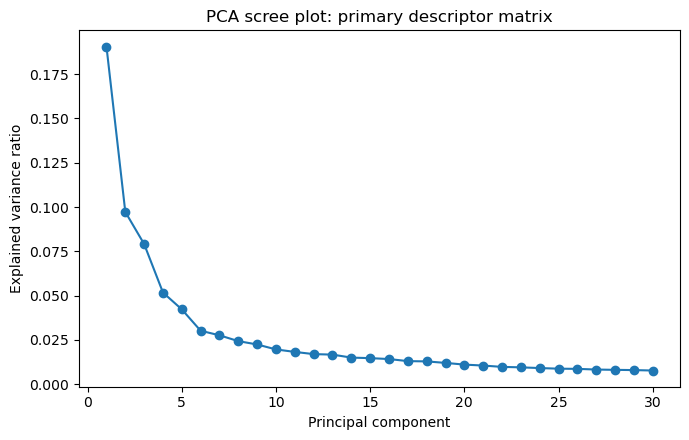

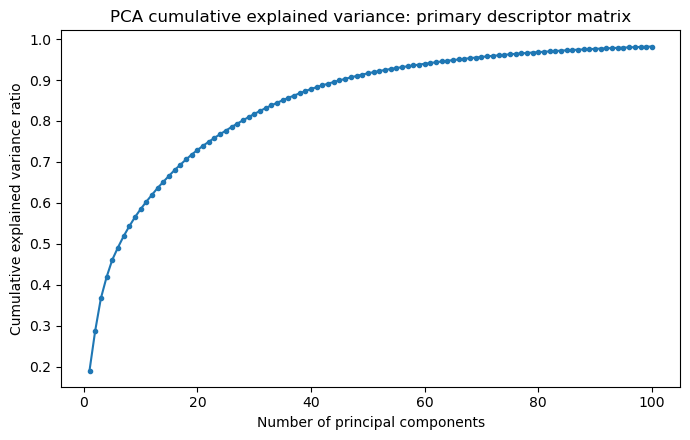

In [45]:
primary = pca_results["primary_remove_constant_only"]
primary_explained = primary["explained"]

primary_explained.to_csv(RESULTS_DIR / "pca_explained_variance_primary.csv", index=False)

plt.figure(figsize=(7, 4.5))
plot_df = primary_explained.head(30)
plt.plot(plot_df["component_index"], plot_df["explained_variance_ratio"], marker="o")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA scree plot: primary descriptor matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scree_plot_first_30_pcs.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 4.5))
plot_df = primary_explained.head(100)
plt.plot(plot_df["component_index"], plot_df["cumulative_explained_variance_ratio"], marker="o", markersize=3)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("PCA cumulative explained variance: primary descriptor matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cumulative_explained_variance_first_100_pcs.png", dpi=200)
plt.show()


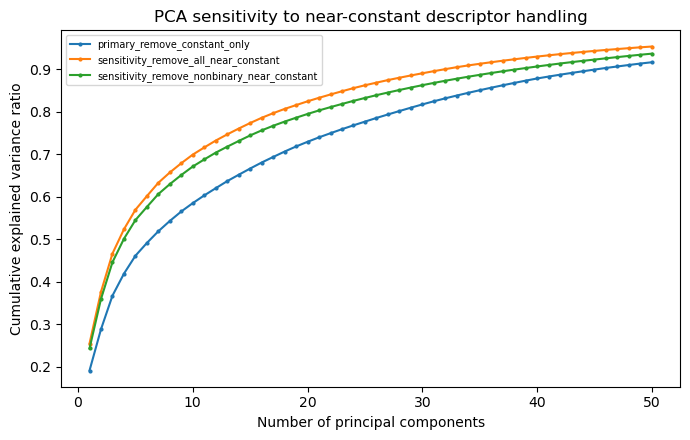

In [46]:
# Compare cumulative explained variance across the three preprocessing choices.
plt.figure(figsize=(7, 4.5))
for name, grp in pca_explained_all.groupby("dataset_name"):
    grp = grp.head(50)
    plt.plot(grp["component_index"], grp["cumulative_explained_variance_ratio"], marker="o", markersize=2, label=name)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("PCA sensitivity to near-constant descriptor handling")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_cumulative_variance_sensitivity_comparison.png", dpi=200)
plt.show()


# 7. PCA Score Space

The score plots show compounds in the low-dimensional descriptor space. pIC50 and ADMET variables are used only as overlays.


In [47]:
activity_smiles_col = activity_train.columns[0]
admet_smiles_col = admet_train.columns[0]

activity_for_merge = activity_train[
    [activity_smiles_col, "IC50_nM", "pIC50"]
].copy()

activity_for_merge = activity_for_merge.rename(
    columns={activity_smiles_col: "SMILES"}
)

admet_for_merge = admet_train.copy()
admet_for_merge = admet_for_merge.rename(
    columns={admet_smiles_col: "SMILES"}
)

primary_scores_df = primary["scores_df"].copy()

primary_scores_df = primary_scores_df.merge(
    activity_for_merge,
    on="SMILES",
    how="left"
)

primary_scores_df = primary_scores_df.merge(
    admet_for_merge,
    on="SMILES",
    how="left"
)

primary_scores_df.to_csv(
    RESULTS_DIR / "pca_scores_primary_first_20_pcs.csv",
    index=False
)

display(primary_scores_df.head())

,dataset_name,SMILES,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,IC50_nM,pIC50,Caco-2,CYP3A4,hERG,HOB,MN
0,primary_remove_constant_only,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCC3)c4ccc(OCCN5C...,3.927025,-8.780846,-0.259680,3.225442,3.340983,-2.191401,-3.817713,0.858996,1.063643,2.491019,3.354271,-0.663005,-0.319037,0.436733,-1.731235,0.381214,-1.298814,1.419521,4.343573,-1.220606,2.5,8.602060,0,1,1,0,0
1,primary_remove_constant_only,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCCCC3)c4ccc(OCCN...,5.977297,-9.852422,-0.654537,3.188851,4.922416,-3.003741,-3.786187,1.004945,0.135917,1.242068,3.233393,-1.186844,0.091104,0.451791,-0.367754,1.073273,-1.005954,1.195562,4.410275,0.311105,7.5,8.124939,0,1,1,0,0
2,primary_remove_constant_only,Oc1ccc(cc1)[C@H]2Sc3cc(O)ccc3O[C@H]2c4ccc(OCCN...,5.215848,-4.392613,-5.146301,1.945742,4.807485,0.116402,-3.057811,0.524584,0.745450,2.810718,2.292775,-0.414788,0.149518,-0.143161,-0.577688,0.986131,-1.317191,0.865054,2.996039,-2.468382,3.1,8.508638,0,1,1,0,1
3,primary_remove_constant_only,Oc1ccc2O[C@H]([C@@H](CC3CCCCC3)Sc2c1)c4ccc(OCC...,5.637308,-9.635355,-0.614475,3.270752,4.771405,-2.908722,-3.220333,0.913196,0.235282,1.935365,3.119756,-0.548335,-0.167222,0.290868,-1.195411,1.176113,-1.159452,1.951735,4.267501,-0.383444,3.9,8.408935,0,1,1,0,0
4,primary_remove_constant_only,Oc1ccc2O[C@H]([C@@H](Cc3ccccc3)Sc2c1)c4ccc(OCC...,4.422044,-6.911645,-4.776552,3.759088,3.888551,-1.591122,-1.434499,1.194824,0.370274,1.915726,1.830456,-0.799247,-0.111568,-0.620112,0.115787,1.288050,-1.650105,0.065892,3.809908,-1.726225,7.4,8.130768,0,1,1,0,0


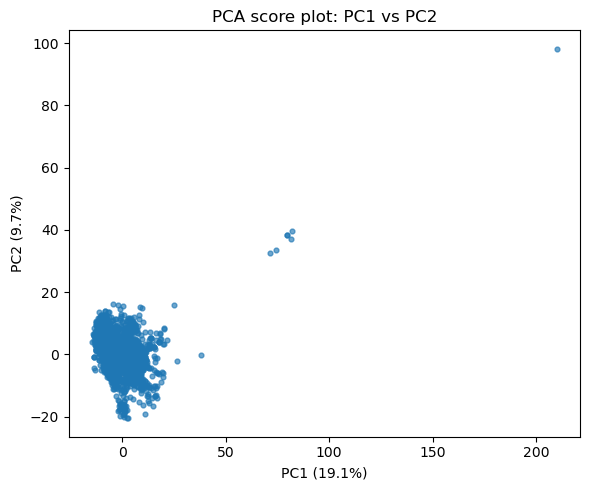

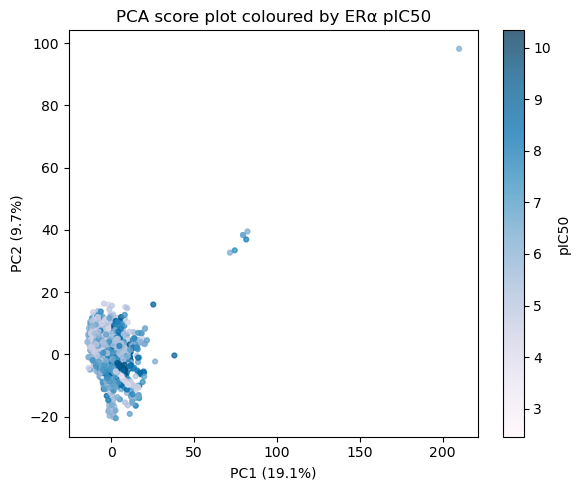

In [48]:
plt.figure(figsize=(6, 5))
plt.scatter(primary_scores_df["PC1"], primary_scores_df["PC2"], s=12, alpha=0.65)
plt.xlabel(f"PC1 ({primary_explained.loc[0, 'explained_variance_ratio']:.1%})")
plt.ylabel(f"PC2 ({primary_explained.loc[1, 'explained_variance_ratio']:.1%})")
plt.title("PCA score plot: PC1 vs PC2")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "score_plot_pc1_pc2.png", dpi=200)
plt.show()

plt.figure(figsize=(6, 5))
sc = plt.scatter(primary_scores_df["PC1"], primary_scores_df["PC2"], c=primary_scores_df["pIC50"], s=12, alpha=0.75, cmap="PuBu")
plt.colorbar(sc, label="pIC50")
plt.xlabel(f"PC1 ({primary_explained.loc[0, 'explained_variance_ratio']:.1%})")
plt.ylabel(f"PC2 ({primary_explained.loc[1, 'explained_variance_ratio']:.1%})")
plt.title("PCA score plot coloured by ERα pIC50")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "score_plot_pc1_pc2_coloured_by_pIC50.png", dpi=200)
plt.show()

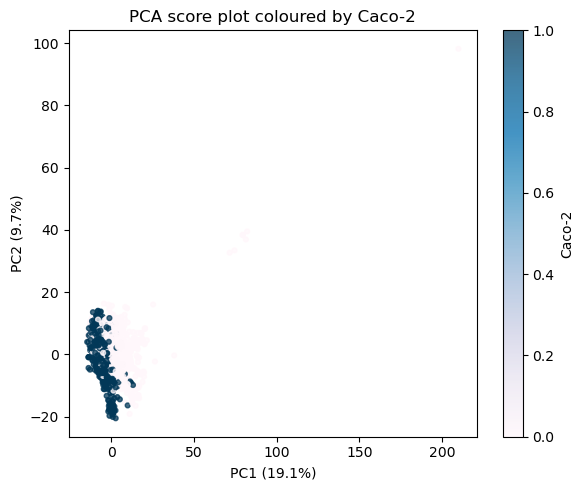

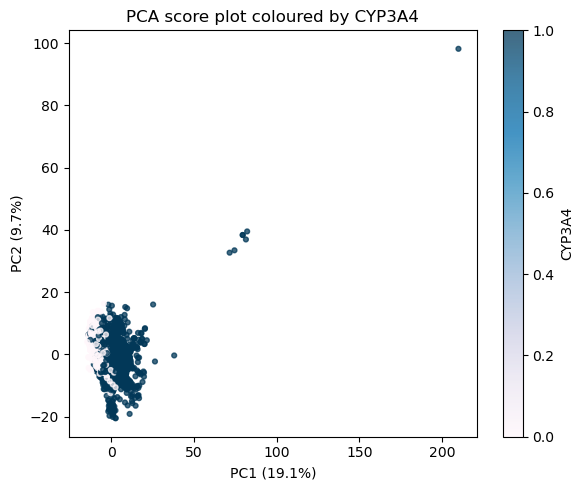

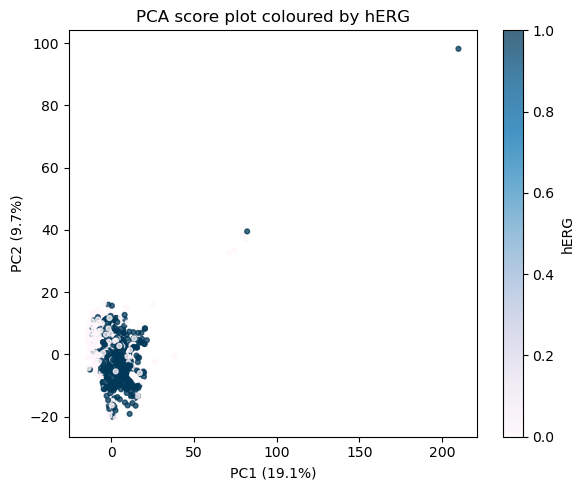

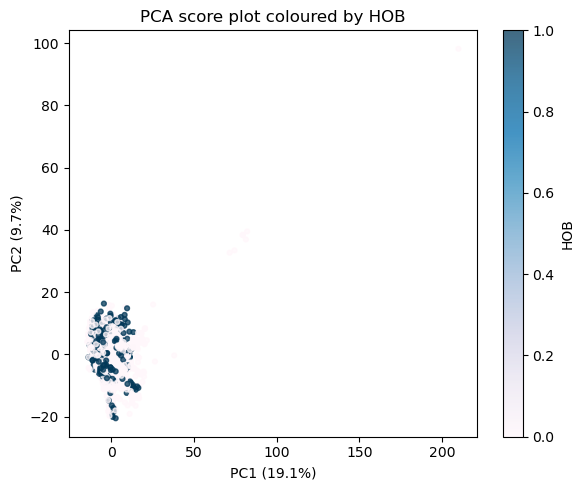

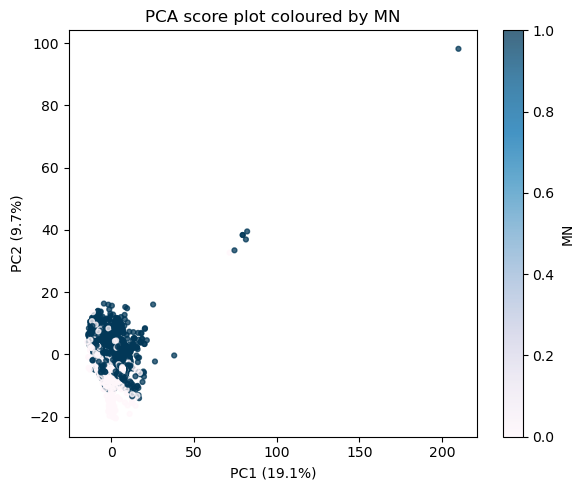

In [49]:
# ADMET overlays: one figure per endpoint.
admet_cols = [c for c in admet_train.columns[1:] if c in primary_scores_df.columns]
for endpoint in admet_cols:
    plt.figure(figsize=(6, 5))
    sc = plt.scatter(primary_scores_df["PC1"], primary_scores_df["PC2"], c=primary_scores_df[endpoint], s=12, alpha=0.75, cmap="PuBu")
    plt.colorbar(sc, label=endpoint)
    plt.xlabel(f"PC1 ({primary_explained.loc[0, 'explained_variance_ratio']:.1%})")
    plt.ylabel(f"PC2 ({primary_explained.loc[1, 'explained_variance_ratio']:.1%})")
    plt.title(f"PCA score plot coloured by {endpoint}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"score_plot_pc1_pc2_coloured_by_{safe_filename(endpoint)}.png", dpi=200)
    plt.show()


# 8. Loading Interpretation

For PCA on standardised descriptors, large absolute loadings indicate descriptors that contribute strongly to a component. These should be interpreted as descriptor patterns, not causal effects.


In [50]:
primary_weights = primary["weights"].copy()
primary_corr_loadings = primary["corr_loadings"].copy()

primary_weights.to_csv(RESULTS_DIR / "pca_weights_primary_first_20_pcs.csv", index=False)
primary_corr_loadings.to_csv(RESULTS_DIR / "pca_correlation_loadings_primary_first_20_pcs.csv", index=False)

# Long table of top loading descriptors for PC1-PC10
top_loading_records = []
for pc_idx in range(1, 11):
    weight_col = f"PC{pc_idx}_weight"
    corr_col = f"PC{pc_idx}_corr_loading"
    if weight_col not in primary_weights.columns:
        continue
    tmp = primary_weights[["descriptor", weight_col]].merge(
        primary_corr_loadings[["descriptor", corr_col]], on="descriptor", how="left"
    )
    tmp["component"] = f"PC{pc_idx}"
    tmp["abs_weight"] = tmp[weight_col].abs()
    tmp["abs_corr_loading"] = tmp[corr_col].abs()
    tmp = tmp.sort_values("abs_weight", ascending=False).head(30)
    top_loading_records.append(tmp)

top_loading_descriptors = pd.concat(top_loading_records, ignore_index=True)

top_loading_descriptors = top_loading_descriptors.merge(
    preprocessing_candidates[[
        "descriptor", "descriptor_category", "descriptor_numeric_type", "is_binary_like", "is_rare_binary_like",
        "is_near_constant", "dominant_value_ratio"
    ]].drop_duplicates("descriptor"),
    on="descriptor",
    how="left",
)

top_loading_descriptors.to_csv(RESULTS_DIR / "pca_top_loading_descriptors_pc1_to_pc10.csv", index=False)
display(top_loading_descriptors.head(30))

,descriptor,PC1_weight,PC1_corr_loading,component,abs_weight,abs_corr_loading,PC2_weight,PC2_corr_loading,PC3_weight,PC3_corr_loading,PC4_weight,PC4_corr_loading,PC5_weight,PC5_corr_loading,PC6_weight,PC6_corr_loading,PC7_weight,PC7_corr_loading,PC8_weight,PC8_corr_loading,PC9_weight,PC9_corr_loading,PC10_weight,PC10_corr_loading,descriptor_category,descriptor_numeric_type,is_binary_like,is_rare_binary_like,is_near_constant,dominant_value_ratio
0,ETA_Eta_R,0.100138,0.981488,PC1,0.100138,0.981488,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Extended topochemical atom,continuous_float_like,False,False,False,0.005572
1,SP-0,0.098993,0.970263,PC1,0.098993,0.970263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chi path,continuous_float_like,False,False,False,0.026342
2,VABC,0.098700,0.967399,PC1,0.098700,0.967399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Van der Waals volume,continuous_float_like,False,False,False,0.010638
3,ETA_Eta,0.098577,0.966187,PC1,0.098577,0.966187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Extended topochemical atom,continuous_float_like,False,False,False,0.003040
4,Kier1,0.098322,0.963689,PC1,0.098322,0.963689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kappa shape indices,continuous_float_like,False,False,False,0.057751
5,VP-0,0.098217,0.962659,PC1,0.098217,0.962659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chi path,continuous_float_like,False,False,False,0.006079
6,McGowan_Volume,0.098040,0.960922,PC1,0.098040,0.960922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,McGowan volume,continuous_float_like,False,False,False,0.010638
7,nHeavyAtom,0.097975,0.960287,PC1,0.097975,0.960287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Atom count,integer_count_like,False,False,False,0.079534
8,SP-2,0.097769,0.958271,PC1,0.097769,0.958271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chi path,continuous_float_like,False,False,False,0.005572
9,MW,0.097703,0.957625,PC1,0.097703,0.957625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Weight,continuous_float_like,False,False,False,0.010638


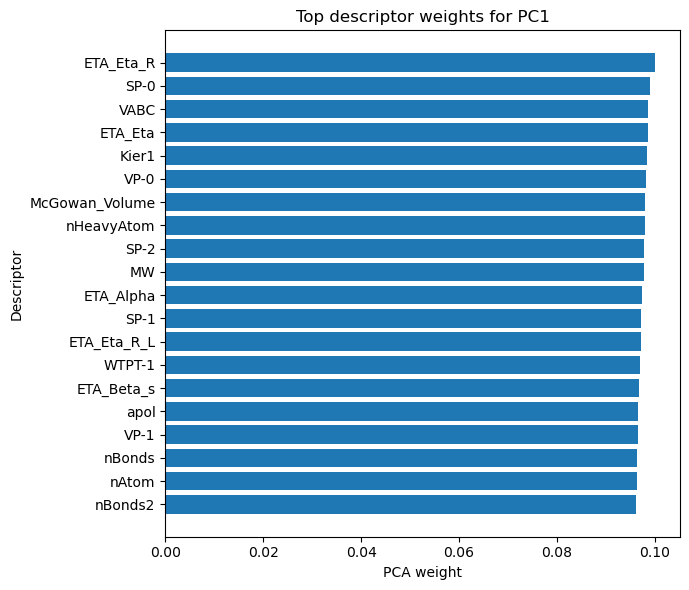

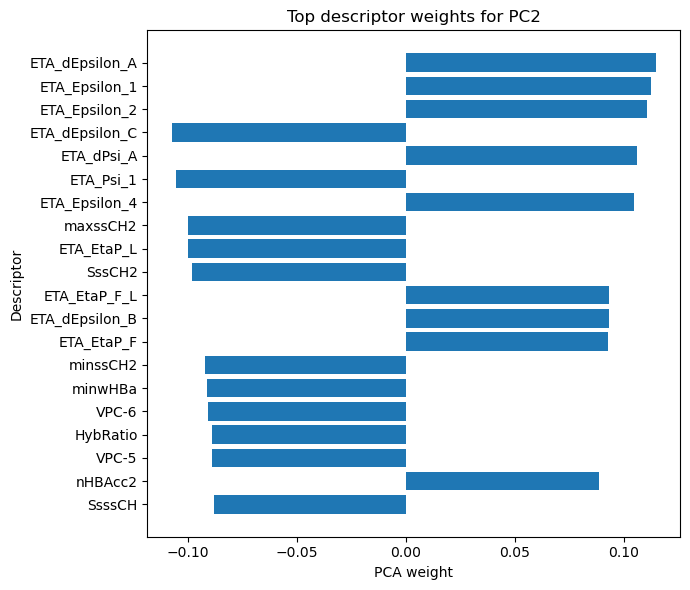

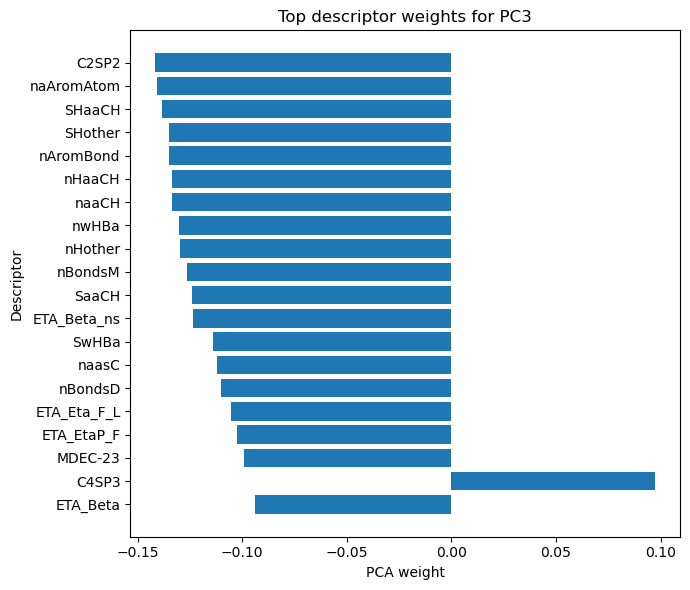

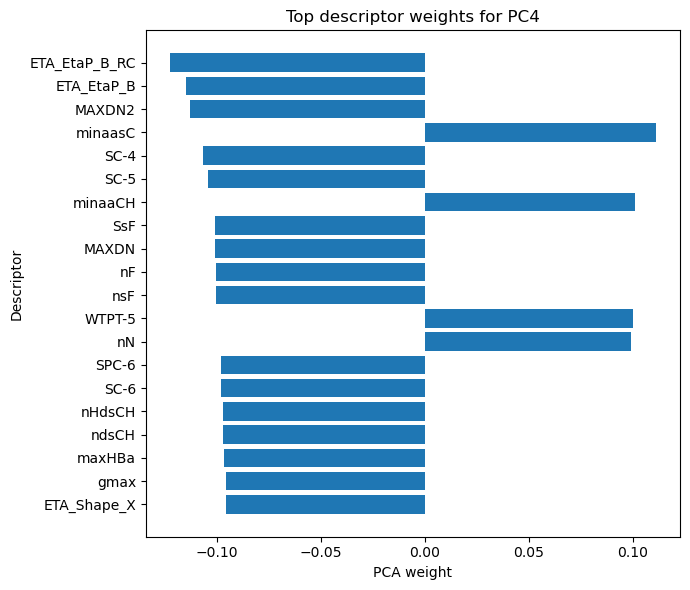

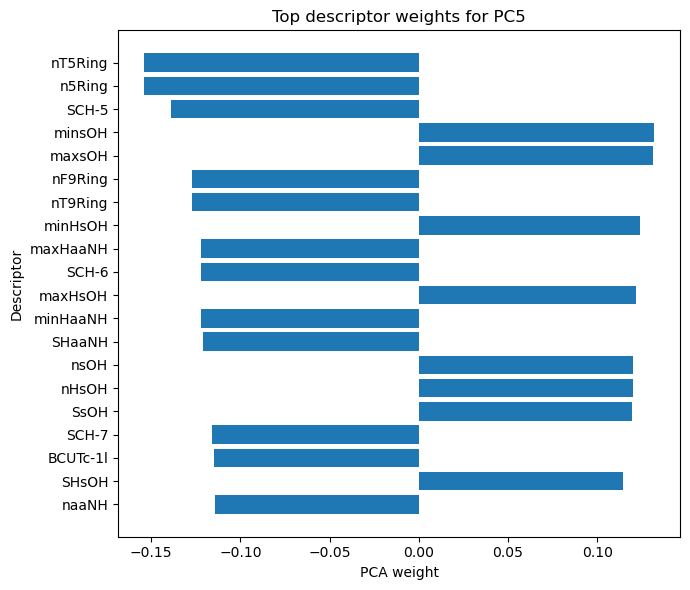

In [51]:
# Plot top loading descriptors for PC1-PC5
for pc_idx in range(1, 6):
    component = f"PC{pc_idx}"
    weight_col = f"PC{pc_idx}_weight"
    tmp = top_loading_descriptors[top_loading_descriptors["component"] == component].copy()
    tmp = tmp.sort_values("abs_weight", ascending=True).tail(20)

    plt.figure(figsize=(7, 6))
    plt.barh(tmp["descriptor"], tmp[weight_col])
    plt.xlabel("PCA weight")
    plt.ylabel("Descriptor")
    plt.title(f"Top descriptor weights for {component}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"top_descriptor_weights_{component}.png", dpi=200)
    plt.show()


# 9. Descriptor Category and Numeric-Type Contributions

In [52]:
# Category contribution based on squared PCA weights.
weights_long_records = []
for pc_idx in range(1, 11):
    weight_col = f"PC{pc_idx}_weight"
    if weight_col not in primary_weights.columns:
        continue
    tmp = primary_weights[["descriptor", weight_col]].copy()
    tmp["component"] = f"PC{pc_idx}"
    tmp["squared_weight"] = tmp[weight_col] ** 2
    weights_long_records.append(tmp[["descriptor", "component", "squared_weight"]])

weights_long = pd.concat(weights_long_records, ignore_index=True)
weights_long = weights_long.merge(
    preprocessing_candidates[[
        "descriptor", "descriptor_category", "descriptor_numeric_type", "is_binary_like", "is_rare_binary_like", "is_near_constant"
    ]].drop_duplicates("descriptor"),
    on="descriptor",
    how="left",
)

category_contribution = (
    weights_long
    .groupby(["component", "descriptor_category"], dropna=False)
    .agg(sum_squared_weight=("squared_weight", "sum"), n_descriptors=("descriptor", "count"))
    .reset_index()
)
category_contribution["component_total_squared_weight"] = category_contribution.groupby("component")["sum_squared_weight"].transform("sum")
category_contribution["prop_component_squared_weight"] = category_contribution["sum_squared_weight"] / category_contribution["component_total_squared_weight"]
category_contribution = category_contribution.sort_values(["component", "prop_component_squared_weight"], ascending=[True, False])
category_contribution.to_csv(RESULTS_DIR / "pca_category_contributions_pc1_to_pc10.csv", index=False)

type_contribution = (
    weights_long
    .groupby(["component", "descriptor_numeric_type"], dropna=False)
    .agg(sum_squared_weight=("squared_weight", "sum"), n_descriptors=("descriptor", "count"))
    .reset_index()
)
type_contribution["component_total_squared_weight"] = type_contribution.groupby("component")["sum_squared_weight"].transform("sum")
type_contribution["prop_component_squared_weight"] = type_contribution["sum_squared_weight"] / type_contribution["component_total_squared_weight"]
type_contribution.to_csv(RESULTS_DIR / "pca_numeric_type_contributions_pc1_to_pc10.csv", index=False)

display(category_contribution.head(20))
display(type_contribution.head(20))

,component,descriptor_category,sum_squared_weight,n_descriptors,component_total_squared_weight,prop_component_squared_weight
6,PC1,Atom type electrotopological state,0.248450,270,1.0,0.248450
17,PC1,Chi path,0.119504,16,1.0,0.119504
21,PC1,Extended topochemical atom,0.111671,43,1.0,0.111671
13,PC1,Bond count,0.050201,9,1.0,0.050201
5,PC1,Atom count,0.041495,13,1.0,0.041495
9,PC1,Autocorrelation (polarizability),0.040284,5,1.0,0.040284
34,PC1,Molecular linear free energy relation,0.034338,6,1.0,0.034338
8,PC1,Autocorrelation (mass),0.034098,5,1.0,0.034098
27,PC1,Kappa shape indices,0.026033,3,1.0,0.026033
18,PC1,Chi path cluster,0.022126,6,1.0,0.022126


,component,descriptor_numeric_type,sum_squared_weight,n_descriptors,component_total_squared_weight,prop_component_squared_weight
0,PC1,binary_like,0.003370,16,1.0,0.003370
1,PC1,continuous_float_like,0.704410,359,1.0,0.704410
2,PC1,integer_count_like,0.143873,27,1.0,0.143873
3,PC1,integer_low_cardinality,0.148347,102,1.0,0.148347
4,PC10,binary_like,0.020269,16,1.0,0.020269
5,PC10,continuous_float_like,0.715438,359,1.0,0.715438
6,PC10,integer_count_like,0.009599,27,1.0,0.009599
7,PC10,integer_low_cardinality,0.254694,102,1.0,0.254694
8,PC2,binary_like,0.003481,16,1.0,0.003481
9,PC2,continuous_float_like,0.771380,359,1.0,0.771380


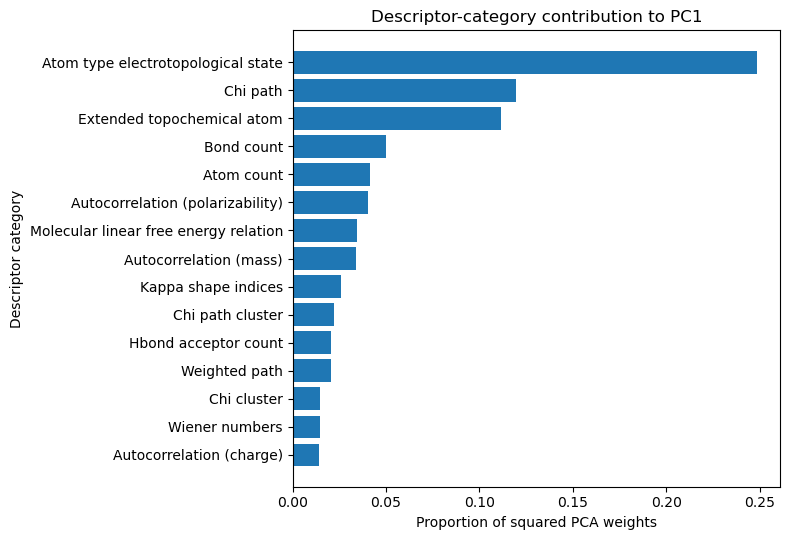

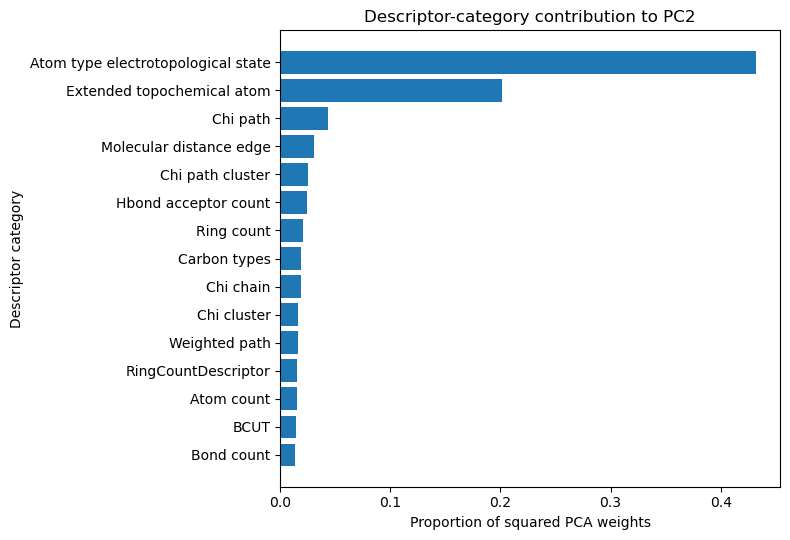

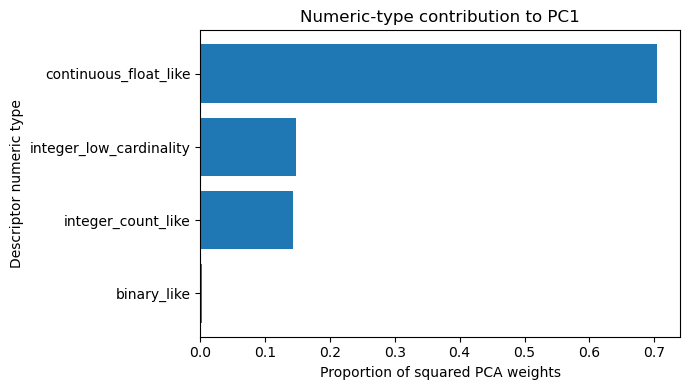

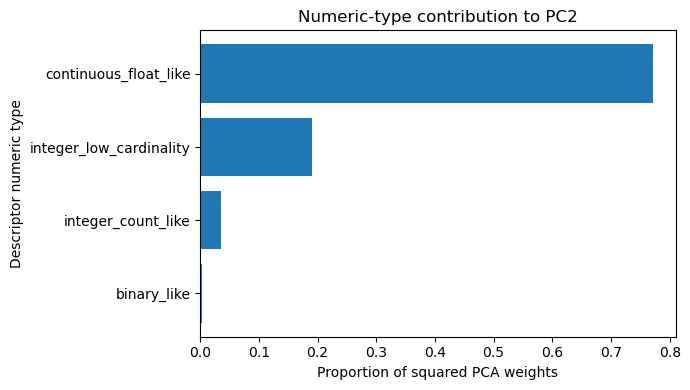

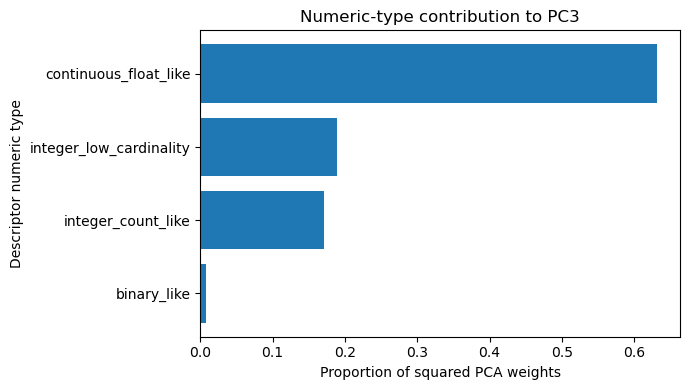

In [53]:
# Plot top descriptor-category contributions for PC1 and PC2
for component in ["PC1", "PC2"]:
    tmp = category_contribution[category_contribution["component"] == component].copy()
    tmp = tmp.sort_values("prop_component_squared_weight", ascending=True).tail(15)

    plt.figure(figsize=(8, 5.5))
    plt.barh(tmp["descriptor_category"], tmp["prop_component_squared_weight"])
    plt.xlabel("Proportion of squared PCA weights")
    plt.ylabel("Descriptor category")
    plt.title(f"Descriptor-category contribution to {component}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"category_contribution_{component}.png", dpi=200)
    plt.show()

# Numeric type contribution plot.
for component in ["PC1", "PC2", "PC3"]:
    tmp = type_contribution[type_contribution["component"] == component].copy()
    tmp = tmp.sort_values("prop_component_squared_weight", ascending=True)

    plt.figure(figsize=(7, 4))
    plt.barh(tmp["descriptor_numeric_type"].astype(str), tmp["prop_component_squared_weight"])
    plt.xlabel("Proportion of squared PCA weights")
    plt.ylabel("Descriptor numeric type")
    plt.title(f"Numeric-type contribution to {component}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"numeric_type_contribution_{component}.png", dpi=200)
    plt.show()


In [54]:
# Size-normalised descriptor-category contribution
category_contribution["mean_squared_weight"] = (
    category_contribution["sum_squared_weight"] /
    category_contribution["n_descriptors"]
)

category_contribution.to_csv(
    RESULTS_DIR / "pca_category_contributions_pc1_to_pc10.csv",
    index=False,
)

size_normalised_category_contribution = category_contribution.sort_values(
    ["component", "mean_squared_weight"],
    ascending=[True, False],
)

size_normalised_category_contribution.to_csv(
    RESULTS_DIR / "pca_size_normalised_category_contributions_pc1_to_pc10.csv",
    index=False,
)

display(size_normalised_category_contribution.head(30))

,component,descriptor_category,sum_squared_weight,n_descriptors,component_total_squared_weight,prop_component_squared_weight,mean_squared_weight
41,PC1,Van der Waals volume,0.009742,1,1.0,0.009742,0.009742
32,PC1,McGowan volume,0.009612,1,1.0,0.009612,0.009612
43,PC1,Weight,0.009546,1,1.0,0.009546,0.009546
1,PC1,APol,0.009340,1,1.0,0.009340,0.009340
47,PC1,Zagreb index,0.009226,1,1.0,0.009226,0.009226
20,PC1,Eccentric connectivity index,0.008990,1,1.0,0.008990,0.008990
11,PC1,BPol,0.008731,1,1.0,0.008731,0.008731
27,PC1,Kappa shape indices,0.026033,3,1.0,0.026033,0.008678
23,PC1,Fragment complexity,0.008424,1,1.0,0.008424,0.008424
9,PC1,Autocorrelation (polarizability),0.040284,5,1.0,0.040284,0.008057


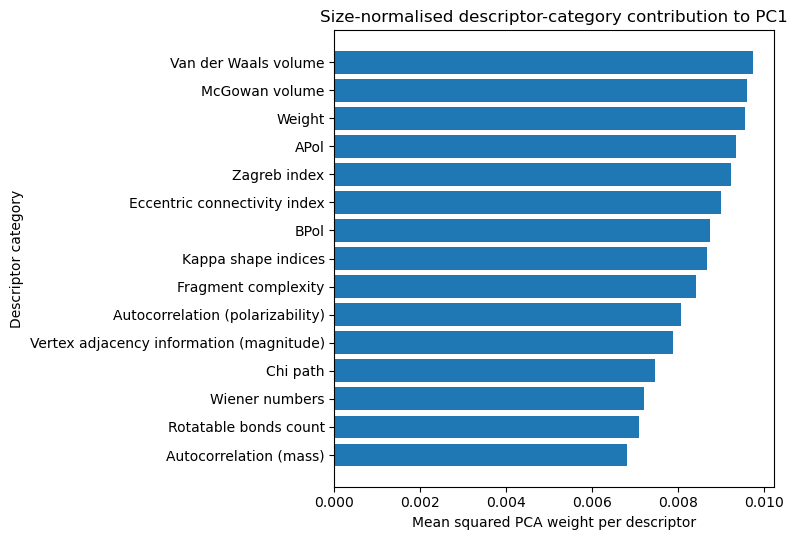

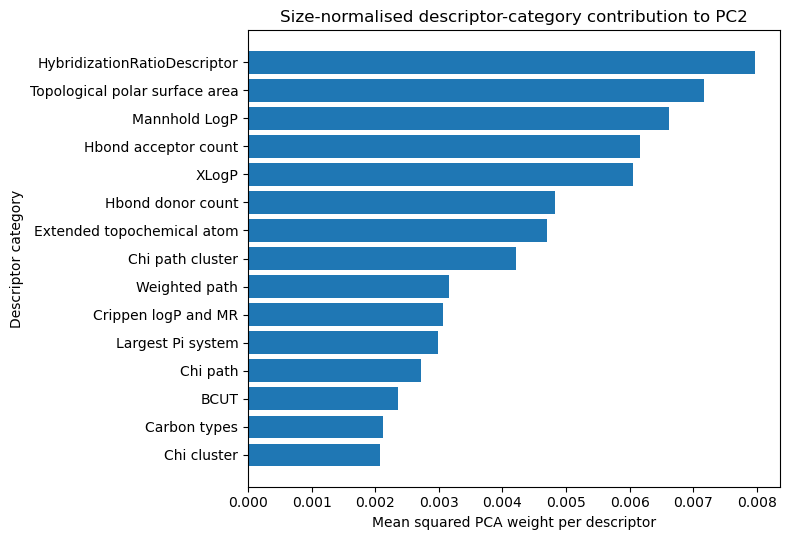

In [55]:
# Plot size-normalised descriptor-category contribution for PC1 and PC2
for component in ["PC1", "PC2"]:
    tmp = size_normalised_category_contribution[
        size_normalised_category_contribution["component"] == component
    ].copy()
    
    tmp = tmp.sort_values("mean_squared_weight", ascending=True).tail(15)

    plt.figure(figsize=(8, 5.5))
    plt.barh(
        tmp["descriptor_category"],
        tmp["mean_squared_weight"],
    )
    plt.xlabel("Mean squared PCA weight per descriptor")
    plt.ylabel("Descriptor category")
    plt.title(f"Size-normalised descriptor-category contribution to {component}")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"size_normalised_category_contribution_{component}.png",
        dpi=200,
    )
    plt.show()

In [56]:
# Candidate super-block contribution to PC1-PC10
weights_with_blocks = weights_long.merge(
    preprocessing_candidates[
        ["descriptor", "candidate_super_block"]
    ].drop_duplicates("descriptor"),
    on="descriptor",
    how="left",
)

weights_with_blocks["candidate_super_block"] = (
    weights_with_blocks["candidate_super_block"]
    .fillna("not_assigned")
)

block_contribution = (
    weights_with_blocks
    .groupby(["component", "candidate_super_block"], dropna=False)
    .agg(
        sum_squared_weight=("squared_weight", "sum"),
        mean_squared_weight=("squared_weight", "mean"),
        n_descriptors=("descriptor", "count"),
    )
    .reset_index()
)

block_contribution["component_total_squared_weight"] = (
    block_contribution
    .groupby("component")["sum_squared_weight"]
    .transform("sum")
)

block_contribution["prop_component_squared_weight"] = (
    block_contribution["sum_squared_weight"] /
    block_contribution["component_total_squared_weight"]
)

block_contribution = block_contribution.sort_values(
    ["component", "prop_component_squared_weight"],
    ascending=[True, False],
)

block_contribution.to_csv(
    RESULTS_DIR / "pca_candidate_super_block_contributions_pc1_to_pc10.csv",
    index=False,
)

display(block_contribution.head(30))

,component,candidate_super_block,sum_squared_weight,mean_squared_weight,n_descriptors,component_total_squared_weight,prop_component_squared_weight
0,PC1,block_X_local_electronic_atom_environment,0.451362,0.001347,335,1.0,0.451362
1,PC1,block_Y_topological_connectivity_structure,0.341722,0.002649,129,1.0,0.341722
2,PC1,not_assigned,0.206916,0.005173,40,1.0,0.206916
3,PC10,block_X_local_electronic_atom_environment,0.679458,0.002028,335,1.0,0.679458
4,PC10,block_Y_topological_connectivity_structure,0.303763,0.002355,129,1.0,0.303763
5,PC10,not_assigned,0.016779,0.000419,40,1.0,0.016779
6,PC2,block_X_local_electronic_atom_environment,0.677237,0.002022,335,1.0,0.677237
7,PC2,block_Y_topological_connectivity_structure,0.234553,0.001818,129,1.0,0.234553
8,PC2,not_assigned,0.088210,0.002205,40,1.0,0.088210
9,PC3,block_X_local_electronic_atom_environment,0.621403,0.001855,335,1.0,0.621403


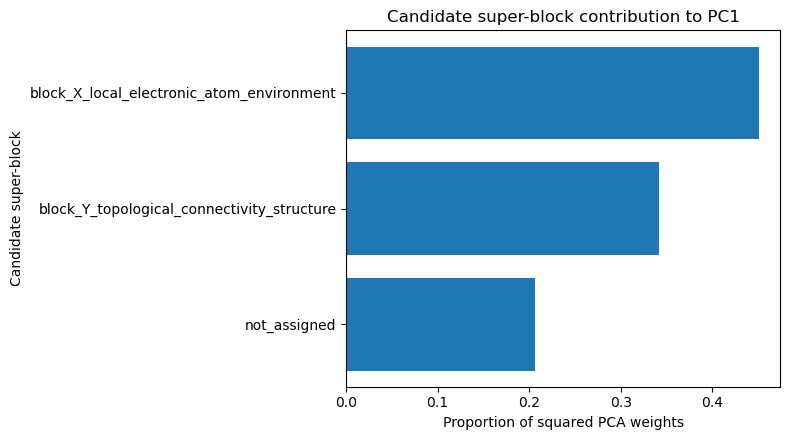

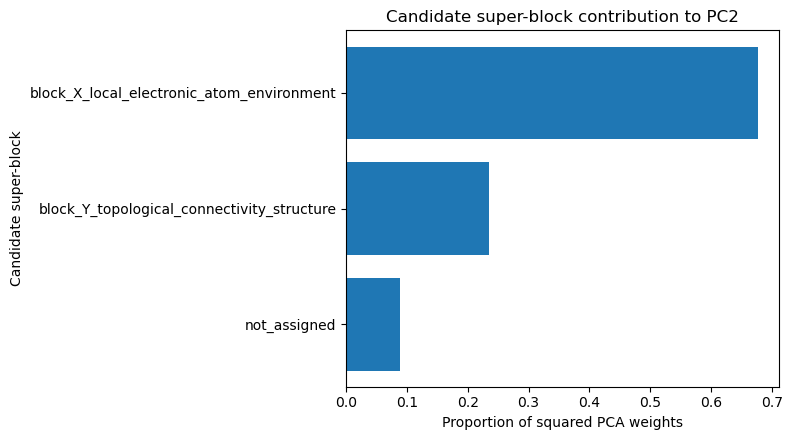

In [57]:
# Plot candidate super-block contribution for PC1 and PC2
for component in ["PC1", "PC2"]:
    tmp = block_contribution[
        block_contribution["component"] == component
    ].copy()
    
    tmp = tmp.sort_values("prop_component_squared_weight", ascending=True)

    plt.figure(figsize=(8, 4.5))
    plt.barh(
        tmp["candidate_super_block"],
        tmp["prop_component_squared_weight"],
    )
    plt.xlabel("Proportion of squared PCA weights")
    plt.ylabel("Candidate super-block")
    plt.title(f"Candidate super-block contribution to {component}")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"candidate_super_block_contribution_{component}.png",
        dpi=200,
    )
    plt.show()

# 10. PCA-Based Compound Outlier Audit

In [65]:
# Retain enough PCs for a preliminary outlier audit
explained = primary["explained"]
threshold_80 = explained.loc[explained["cumulative_explained_variance_ratio"] >= 0.80, "component_index"]
if len(threshold_80) > 0:
    n_outlier_components = int(threshold_80.iloc[0])
else:
    n_outlier_components = min(20, primary["scores"].shape[1])
n_outlier_components = min(max(n_outlier_components, 2), 50, primary["scores"].shape[1])

scores_out = primary["scores"][:, :n_outlier_components]
explained_variance_out = primary["pca"].explained_variance_[:n_outlier_components]

# Hotelling-like T2 in retained PCA space
t2_scores = np.sum((scores_out ** 2) / explained_variance_out, axis=1)

# SPE/Q residual using reconstruction from retained components
pca_model = primary["pca"]
components_retained = pca_model.components_[:n_outlier_components, :]
X_scaled = primary["X_scaled"]
X_reconstructed = scores_out @ components_retained + pca_model.mean_
spe_scores = np.sum((X_scaled - X_reconstructed) ** 2, axis=1)

t2_threshold = np.quantile(t2_scores, 0.99)
spe_threshold = np.quantile(spe_scores, 0.99)

pca_outlier_summary = pd.DataFrame({
    "SMILES": desc_train[smiles_col].astype(str).values,
    "T2_score": t2_scores,
    "SPE_score": spe_scores,
    "flag_T2_ge_empirical_99pct": t2_scores >= t2_threshold,
    "flag_SPE_ge_empirical_99pct": spe_scores >= spe_threshold,
})
pca_outlier_summary["flag_pca_outlier_empirical"] = (
    pca_outlier_summary["flag_T2_ge_empirical_99pct"] | pca_outlier_summary["flag_SPE_ge_empirical_99pct"]
)

pca_outlier_summary = pca_outlier_summary.merge(
    primary_scores_df[["SMILES", "pIC50"]],
    on="SMILES",
    how="left"
)

pca_outlier_summary = pca_outlier_summary.sort_values(
    ["flag_pca_outlier_empirical", "T2_score", "SPE_score"],
    ascending=[False, False, False]
)
pca_outlier_summary["flag_reason"] = np.select(
    [
        pca_outlier_summary["flag_T2_ge_empirical_99pct"] 
        & pca_outlier_summary["flag_SPE_ge_empirical_99pct"],
        pca_outlier_summary["flag_T2_ge_empirical_99pct"],
        pca_outlier_summary["flag_SPE_ge_empirical_99pct"],
    ],
    [
        "T2_and_SPE",
        "T2_only",
        "SPE_only",
    ],
    default="not_flagged",
)

pca_outlier_summary.to_csv(RESULTS_DIR / "pca_compound_outlier_summary_empirical.csv", index=False)

print("PCA components used for outlier audit:", n_outlier_components)
print("Flagged PCA outliers:", int(pca_outlier_summary["flag_pca_outlier_empirical"].sum()))
display(pca_outlier_summary.head(20))
display(
    pca_outlier_summary["flag_reason"]
    .value_counts()
    .rename_axis("flag_reason")
    .reset_index(name="n_compounds")
)

PCA components used for outlier audit: 28
Flagged PCA outliers: 35


,SMILES,T2_score,SPE_score,flag_T2_ge_empirical_99pct,flag_SPE_ge_empirical_99pct,flag_pca_outlier_empirical,pIC50,flag_reason
1112,Cc1ccc(cc1)c2nnc(S)n2\N=C\C=C/c3ccccc3[N+](=O)...,1908.321747,233.444899,True,False,True,5.135690,T2_only
1562,CC[C@H](C)[C@@H]1NC(=O)[C@@H](CSSC[C@H](NC(=O)...,1394.328481,1453.974704,True,True,True,6.125518,T2_and_SPE
1182,CCOP(=O)(OCC)C1(NS(=O)(=O)c2ccccc2)C=C(Br)C(=O...,870.168199,525.231113,True,False,True,5.061065,T2_only
1152,CCOP(=O)(OCC)C1(NS(=O)(=O)c2ccccc2)C=C(Cl)C(=O...,776.230501,658.290433,True,True,True,4.900007,T2_and_SPE
1878,CCCCCCCCOC(=O)c1cc(I)c(O)c(I)c1,739.736545,254.978895,True,False,True,4.879426,T2_only
1874,CCCCOC(=O)c1cc(I)c(O)c(I)c1,694.055762,377.786735,True,False,True,4.460924,T2_only
1686,Cc1c(c2ccc(O)cc2)n(Cc3ccc(OCC[N+](C)(C)C)cc3)c...,595.380344,5420.746848,True,True,True,7.000000,T2_and_SPE
1875,CCCCOC(=O)c1ccc(O)c(I)c1,228.226589,460.305453,True,False,True,5.097997,T2_only
1566,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1cnc[nH]1)NC(=O)...,204.913107,527.371776,True,False,True,6.207608,T2_only
1567,CC[C@H](C)[C@@H]1NC(=O)[C@@H](CSSC[C@H](NC(=O)...,193.885454,519.598622,True,False,True,7.886057,T2_only


,flag_reason,n_compounds
0,not_flagged,1939
1,T2_only,15
2,SPE_only,15
3,T2_and_SPE,5


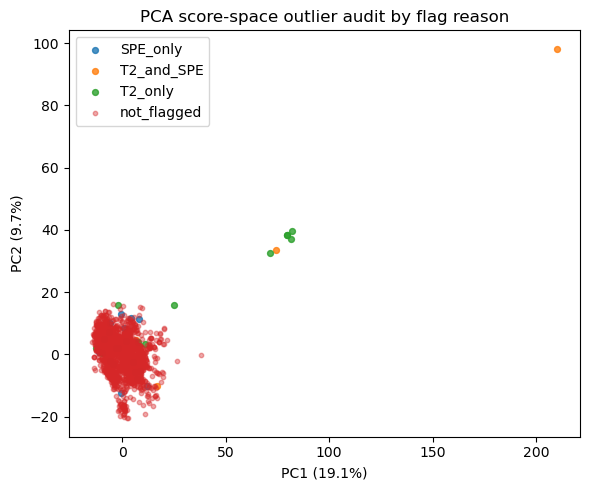

In [63]:
plot_df = primary_scores_df[["SMILES", "PC1", "PC2"]].merge(
    pca_outlier_summary[["SMILES", "flag_reason"]],
    on="SMILES",
    how="left"
)

plt.figure(figsize=(6, 5))

for reason, group in plot_df.groupby("flag_reason"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        s=18 if reason != "not_flagged" else 10,
        alpha=0.8 if reason != "not_flagged" else 0.4,
        label=reason,
    )

plt.xlabel(f"PC1 ({primary_explained.loc[0, 'explained_variance_ratio']:.1%})")
plt.ylabel(f"PC2 ({primary_explained.loc[1, 'explained_variance_ratio']:.1%})")
plt.title("PCA score-space outlier audit by flag reason")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "score_plot_pc1_pc2_pca_outlier_flag_reason.png", dpi=200)
plt.show()

# 11. Candidate Super-Block PCA Diagnostics

Candidate super-blocks:
- block_Y_topological_connectivity_structure
- block_X_local_electronic_atom_environment

Super-block: block_Y_topological_connectivity_structure
Number of nonconstant descriptors: 129


,dataset_name,component,component_index,explained_variance,explained_variance_ratio,cumulative_explained_variance_ratio
0,superblock_block_Y_topological_connectivity_st...,PC1,1,37.304148,0.289033,0.289033
1,superblock_block_Y_topological_connectivity_st...,PC2,2,15.375607,0.119130,0.408163
2,superblock_block_Y_topological_connectivity_st...,PC3,3,9.798853,0.075922,0.484085
3,superblock_block_Y_topological_connectivity_st...,PC4,4,7.898001,0.061194,0.545279
4,superblock_block_Y_topological_connectivity_st...,PC5,5,5.219419,0.040440,0.585719
5,superblock_block_Y_topological_connectivity_st...,PC6,6,4.674314,0.036217,0.621935
6,superblock_block_Y_topological_connectivity_st...,PC7,7,4.387819,0.033997,0.655932
7,superblock_block_Y_topological_connectivity_st...,PC8,8,3.509327,0.027190,0.683123
8,superblock_block_Y_topological_connectivity_st...,PC9,9,3.088845,0.023932,0.707055
9,superblock_block_Y_topological_connectivity_st...,PC10,10,2.969162,0.023005,0.730060


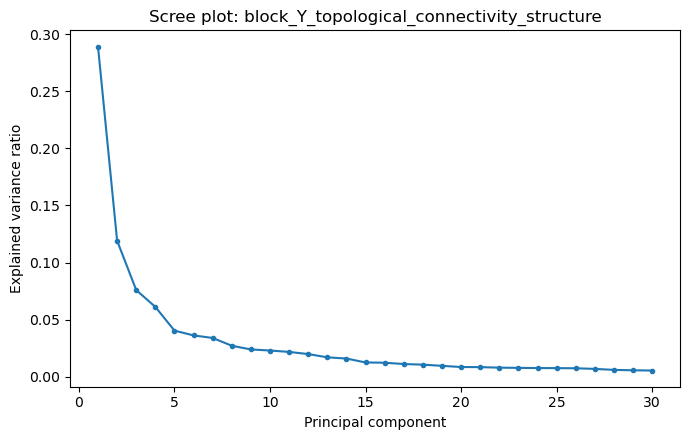

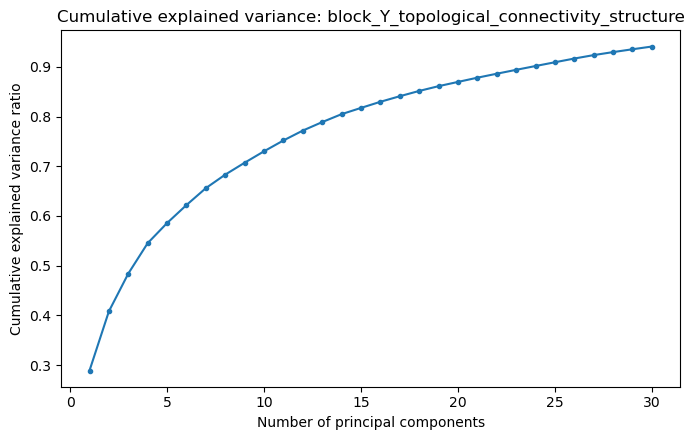

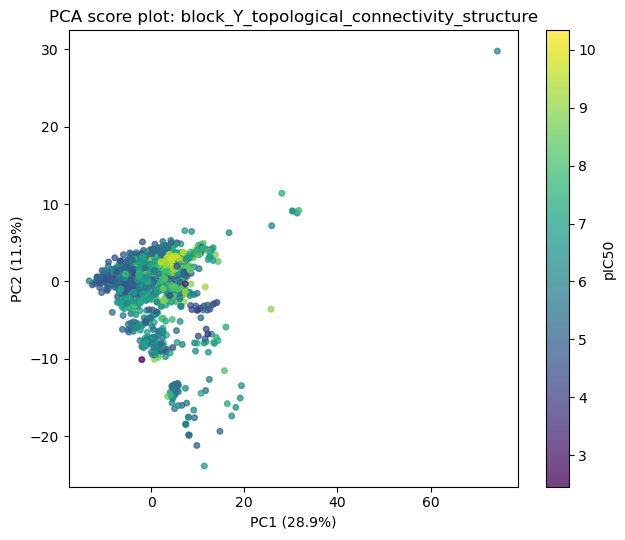

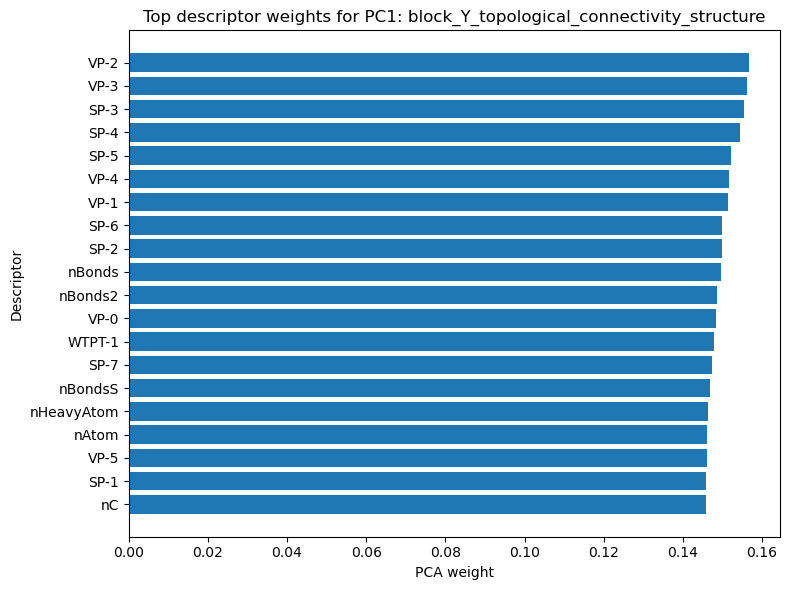

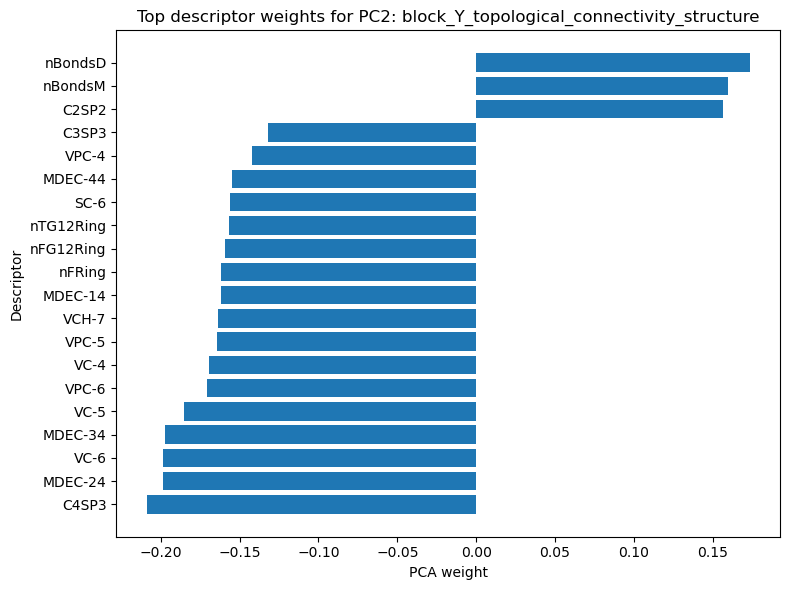


Super-block: block_X_local_electronic_atom_environment
Number of nonconstant descriptors: 335


,dataset_name,component,component_index,explained_variance,explained_variance_ratio,cumulative_explained_variance_ratio
0,superblock_block_X_local_electronic_atom_envir...,PC1,1,46.789926,0.139601,0.139601
1,superblock_block_X_local_electronic_atom_envir...,PC2,2,33.244047,0.099186,0.238786
2,superblock_block_X_local_electronic_atom_envir...,PC3,3,24.577334,0.073328,0.312114
3,superblock_block_X_local_electronic_atom_envir...,PC4,4,18.527461,0.055278,0.367392
4,superblock_block_X_local_electronic_atom_envir...,PC5,5,15.716737,0.046892,0.414284
5,superblock_block_X_local_electronic_atom_envir...,PC6,6,11.843496,0.035336,0.449620
6,superblock_block_X_local_electronic_atom_envir...,PC7,7,10.325110,0.030806,0.480425
7,superblock_block_X_local_electronic_atom_envir...,PC8,8,9.868091,0.029442,0.509868
8,superblock_block_X_local_electronic_atom_envir...,PC9,9,8.495358,0.025346,0.535214
9,superblock_block_X_local_electronic_atom_envir...,PC10,10,8.316051,0.024811,0.560025


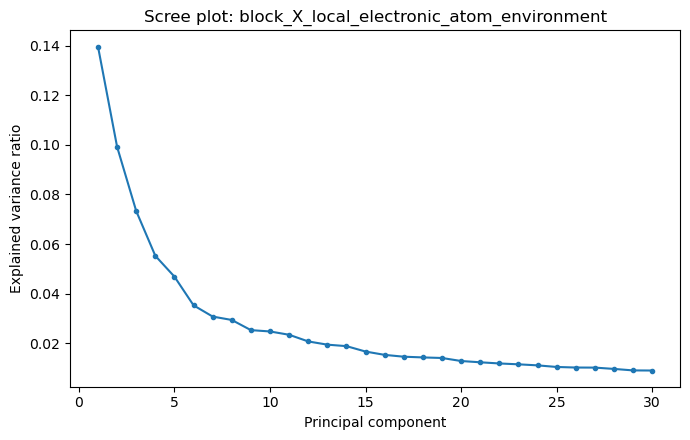

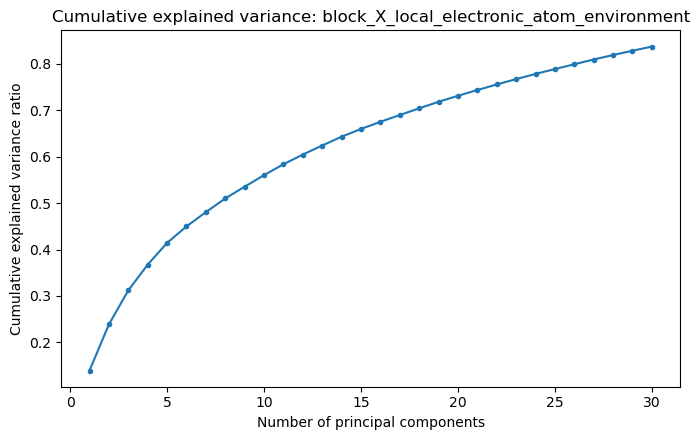

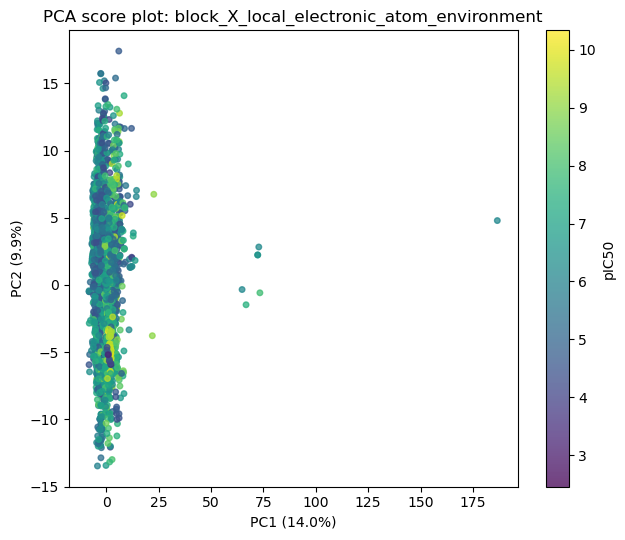

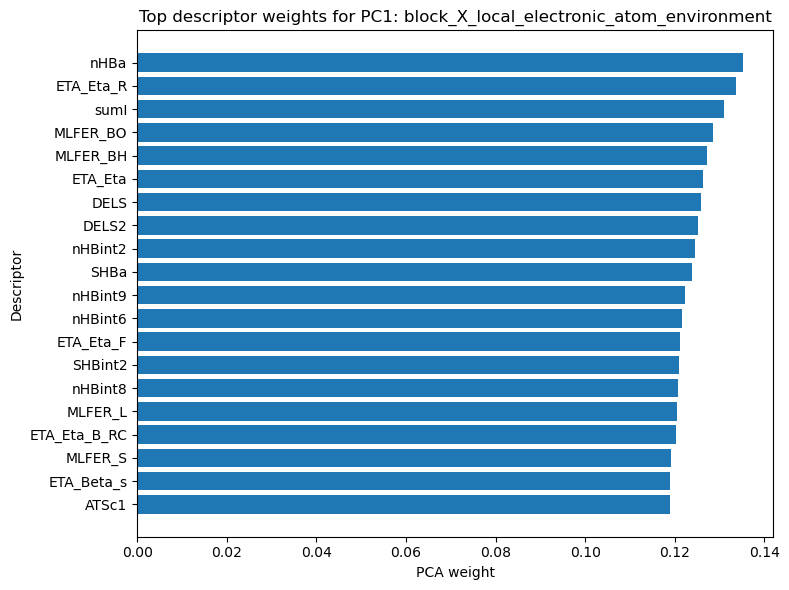

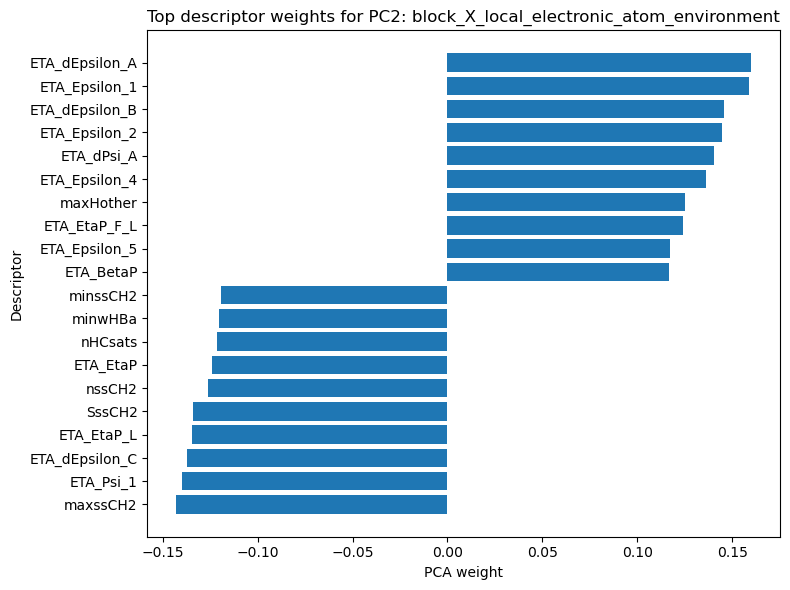

In [60]:
# Separate PCA diagnostics for each candidate super-block

superblock_pca_results = {}
superblock_pca_summary_records = []

assigned_superblocks = (
    preprocessing_candidates
    .loc[
        preprocessing_candidates["candidate_super_block"] != "not_assigned",
        "candidate_super_block"
    ]
    .dropna()
    .unique()
    .tolist()
)

print("Candidate super-blocks:")
for block in assigned_superblocks:
    print("-", block)

for block_name in assigned_superblocks:
    block_descriptors = (
        preprocessing_candidates
        .loc[
            (preprocessing_candidates["candidate_super_block"] == block_name)
            & (preprocessing_candidates["is_constant"] == False),
            "descriptor"
        ]
        .tolist()
    )
    
    block_descriptors = [
        d for d in block_descriptors
        if d in X_train.columns
    ]
    
    print("\n" + "=" * 80)
    print("Super-block:", block_name)
    print("Number of nonconstant descriptors:", len(block_descriptors))
    
    block_result = fit_standardised_pca(
        X_train,
        block_descriptors,
        dataset_name=f"superblock_{safe_filename(block_name)}",
        n_components_max=min(50, len(block_descriptors))
    )
    
    superblock_pca_results[block_name] = block_result
    
    explained = block_result["explained"].copy()
    scores_df = block_result["scores_df"].copy()
    weights = block_result["weights"].copy()
    corr_loadings = block_result["corr_loadings"].copy()
    
    block_safe_name = safe_filename(block_name)
    
    explained.to_csv(
        RESULTS_DIR / f"pca_explained_variance_superblock_{block_safe_name}.csv",
        index=False
    )
    
    scores_df.to_csv(
        RESULTS_DIR / f"pca_scores_superblock_{block_safe_name}.csv",
        index=False
    )
    
    weights.to_csv(
        RESULTS_DIR / f"pca_weights_superblock_{block_safe_name}.csv",
        index=False
    )
    
    corr_loadings.to_csv(
        RESULTS_DIR / f"pca_corr_loadings_superblock_{block_safe_name}.csv",
        index=False
    )
    
    block_meta = preprocessing_candidates[
        preprocessing_candidates["descriptor"].isin(block_descriptors)
    ].copy()
    
    n_categories = block_meta["descriptor_category"].nunique()
    
    numeric_type_counts = (
        block_meta["descriptor_numeric_type"]
        .value_counts(dropna=False)
        .to_dict()
    )
    
    superblock_pca_summary_records.append({
        "candidate_super_block": block_name,
        "n_descriptors": len(block_descriptors),
        "n_descriptor_categories": n_categories,
        "pc1_explained_variance_ratio": cumulative_at(explained, 1),
        "pc2_cumulative_explained_variance_ratio": cumulative_at(explained, 2),
        "pc5_cumulative_explained_variance_ratio": cumulative_at(explained, 5),
        "pc10_cumulative_explained_variance_ratio": cumulative_at(explained, 10),
        "pc20_cumulative_explained_variance_ratio": cumulative_at(explained, 20),
        "numeric_type_counts": numeric_type_counts,
    })
    
    display(explained.head(10))
    
    # Scree plot
    plt.figure(figsize=(7, 4.5))
    plot_df = explained.head(30)
    plt.plot(
        plot_df["component_index"],
        plot_df["explained_variance_ratio"],
        marker="o",
        markersize=3
    )
    plt.xlabel("Principal component")
    plt.ylabel("Explained variance ratio")
    plt.title(f"Scree plot: {block_name}")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"scree_plot_superblock_{block_safe_name}.png",
        dpi=200
    )
    plt.show()
    
    # Cumulative explained variance plot
    plt.figure(figsize=(7, 4.5))
    plt.plot(
        plot_df["component_index"],
        plot_df["cumulative_explained_variance_ratio"],
        marker="o",
        markersize=3
    )
    plt.xlabel("Number of principal components")
    plt.ylabel("Cumulative explained variance ratio")
    plt.title(f"Cumulative explained variance: {block_name}")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"cumulative_explained_variance_superblock_{block_safe_name}.png",
        dpi=200
    )
    plt.show()
    
    # PC1-PC2 score plot for this super-block
    if {"PC1", "PC2"}.issubset(scores_df.columns):
        scores_plot_df = scores_df.merge(
                        activity_for_merge[["SMILES", "pIC50"]],
                        on="SMILES",
                        how="left"
                    )
        
        plt.figure(figsize=(6.5, 5.5))
        scatter = plt.scatter(
            scores_plot_df["PC1"],
            scores_plot_df["PC2"],
            c=scores_plot_df["pIC50"],
            s=16,
            alpha=0.75
        )
        plt.colorbar(scatter, label="pIC50")
        plt.xlabel(
            f"PC1 ({explained.loc[explained['component_index'] == 1, 'explained_variance_ratio'].iloc[0]:.1%})"
        )
        plt.ylabel(
            f"PC2 ({explained.loc[explained['component_index'] == 2, 'explained_variance_ratio'].iloc[0]:.1%})"
        )
        plt.title(f"PCA score plot: {block_name}")
        plt.tight_layout()
        plt.savefig(
            FIGURES_DIR / f"score_plot_pc1_pc2_superblock_{block_safe_name}_coloured_by_pIC50.png",
            dpi=200
        )
        plt.show()
    
    # Top descriptor weights for PC1 and PC2
    for pc in ["PC1", "PC2"]:
        weight_col = f"{pc}_weight"
        
        if weight_col not in weights.columns:
            continue
        
        tmp = weights[["descriptor", weight_col]].copy()
        tmp["abs_weight"] = tmp[weight_col].abs()
        tmp = tmp.sort_values("abs_weight", ascending=False).head(20)
        tmp = tmp.sort_values(weight_col)
        
        plt.figure(figsize=(8, 6))
        plt.barh(tmp["descriptor"], tmp[weight_col])
        plt.xlabel("PCA weight")
        plt.ylabel("Descriptor")
        plt.title(f"Top descriptor weights for {pc}: {block_name}")
        plt.tight_layout()
        plt.savefig(
            FIGURES_DIR / f"top_descriptor_weights_{pc}_superblock_{block_safe_name}.png",
            dpi=200
        )
        plt.show()

In [61]:
superblock_pca_summary = pd.DataFrame(superblock_pca_summary_records)

superblock_pca_summary.to_csv(
    RESULTS_DIR / "candidate_super_block_pca_summary.csv",
    index=False
)

display(superblock_pca_summary)

,candidate_super_block,n_descriptors,n_descriptor_categories,pc1_explained_variance_ratio,pc2_cumulative_explained_variance_ratio,pc5_cumulative_explained_variance_ratio,pc10_cumulative_explained_variance_ratio,pc20_cumulative_explained_variance_ratio,numeric_type_counts
0,block_Y_topological_connectivity_structure,129,12,0.289033,0.408163,0.585719,0.730060,0.869577,"{'continuous_float_like': 69, 'integer_low_car..."
1,block_X_local_electronic_atom_environment,335,6,0.139601,0.238786,0.414284,0.560025,0.730795,"{'continuous_float_like': 269, 'integer_low_ca..."
